# 06 · Evaluation and the release gate: the JUDGE layer

**FDE Academy · Accelerator track · Retrieval, RAG and Evals · Lab notebook 6 of 8**

You write every layered metric out so its blind spot is visible, compute the attribution 2x2 over the whole benchmark, calibrate a judge with Cohen's kappa, measure the run-to-run noise band, and let a gate block a change that looks like an improvement.

| How to run | What it needs | Runs before | Runs after |
|---|---|---|---|
| Run All, top to bottom. Every cell executes offline in under a minute or two. | Python 3.10 or later with numpy, pandas, matplotlib and scikit-learn. `boto3` and `tiktoken` are optional and detected automatically. | Notebook 05. | Notebook 07, which prices what this notebook decides to ship. |

The answers scored here come from the documented simulator, whose knobs let you manufacture each failure mode on purpose. The scorers themselves are the real ones and run unchanged on a real model's answers.

## Where this sits on the pipeline

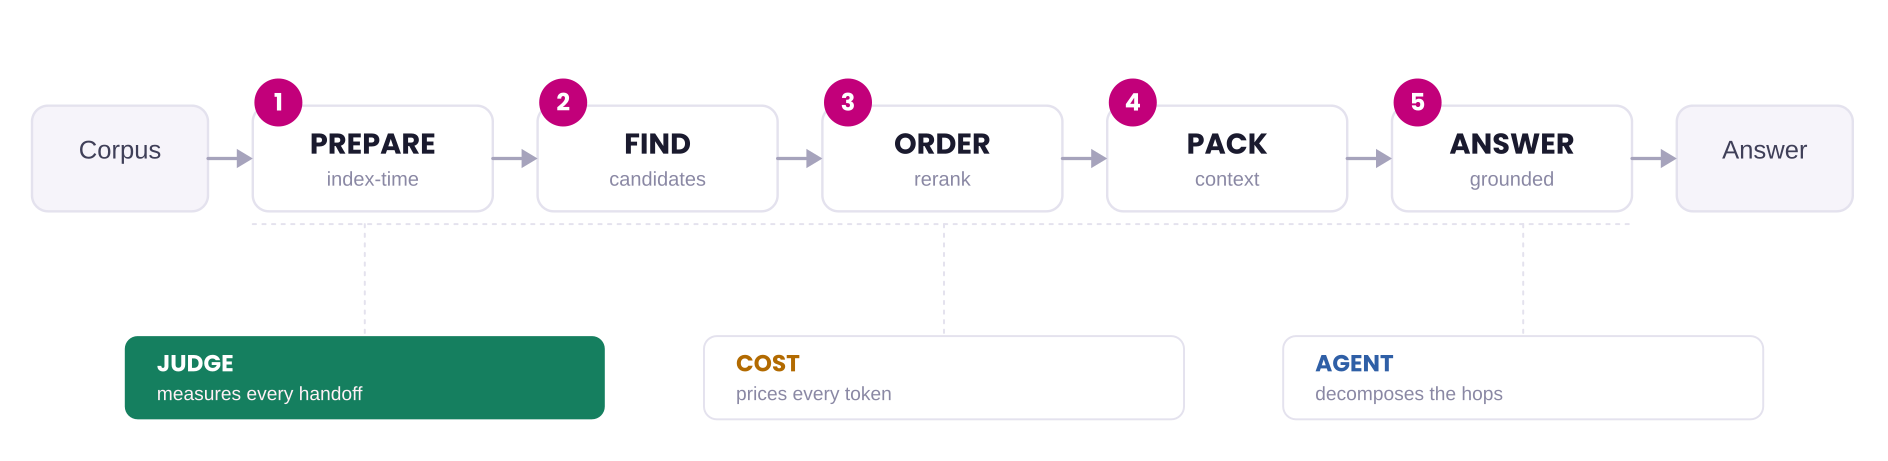

*Evaluation is a layer over every stage, not a step at the end.*

## 1 · Layered metrics, written out

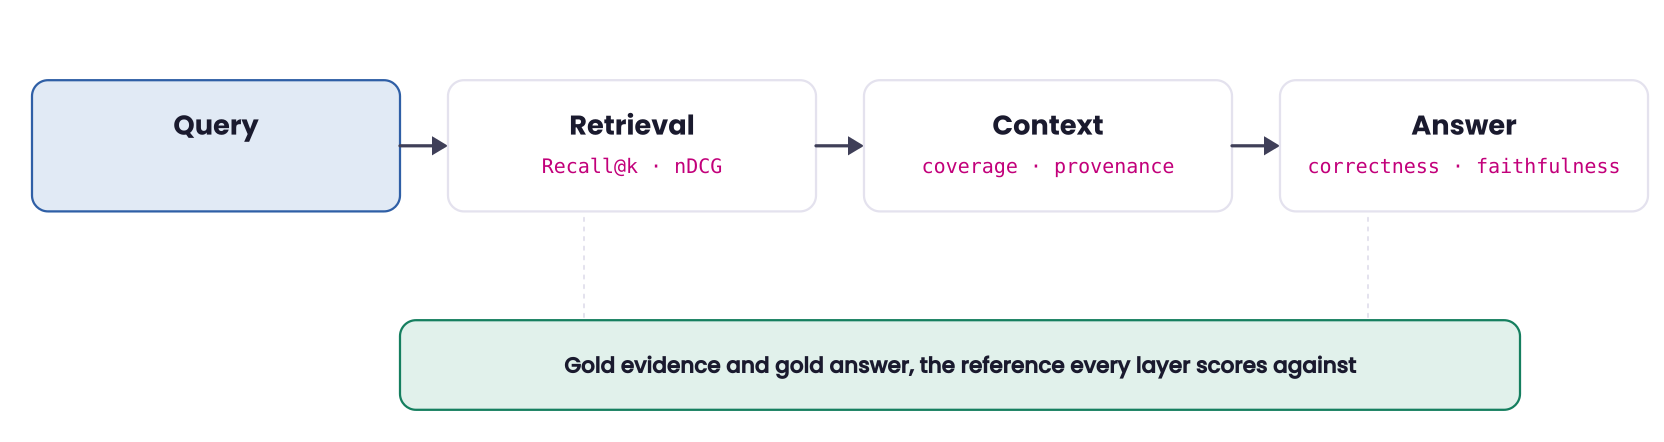

*Own drawing of an established arrangement.*


$$\text{EvidenceRecall@}k = \frac{|\text{gold spans with a carrying chunk in the top }k|}{|\text{gold spans}|} \qquad
\text{FullChainRecall@}k = \mathbb{1}[\text{every gold span has a carrying chunk in the top }k]$$

$$\text{nDCG@}k = \frac{\sum_{i \le k} \mathbb{1}[\text{chunk}_i \in \text{gold}] / \log_2(i+1)}{\text{ideal DCG}} \qquad
\text{Coverage} = \frac{|\text{gold spans present in the packed context}|}{|\text{gold spans}|}$$

$$\text{Faithfulness} = \frac{|\text{gold spans found verbatim in the cited chunks}|}{|\text{gold spans}|} \qquad
\text{Correctness} = \mathbb{1}[\text{gold answer tokens} \subseteq \text{answer tokens}]\ \text{or, for a null question, }\mathbb{1}[\text{abstained}]$$

In [1]:
# One-click setup. The notebook runs offline on numpy, pandas, matplotlib, scikit-learn and sqlite3.
# `ragkit` ships in the same folder as this notebook.
import sys, os
from pathlib import Path
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ragkit").is_dir():
        sys.path.insert(0, str(p)); break
import numpy as np, pandas as pd
import ragkit as rk
from ragkit import table, verdict_style, bars, lines, decision
rk.palette.style()
pd.set_option("display.width", 160)
print("ragkit", rk.__version__, "| provider:", rk.config()["provider"], "| tokenizer:", rk.TOKENIZER)

ragkit 0.1.0 | provider: mock | tokenizer: tiktoken cl100k_base


In [2]:
store, chunks, embedder, retriever, generator, questions = rk.bootstrap(chunker="structural")
texts = {c.chunk_id: c.text for c in chunks}; anchor = rk.ANCHOR; answerable = [q for q in questions if q.gold]
gold_sets = rk.gold_chunk_sets(anchor, chunks)
pool = retriever.hybrid(anchor.text, k=50); pool_ids = [c for c, _ in pool]
rows = []
for k in [5, 20]:
    packed = rk.pack(pool, texts, evidence_cap=6000, k=k); ans = generator.answer(anchor, packed.chunk_ids, texts)
    rows.append({"k": k, "evidence recall@k": rk.evidence_recall_at_k(gold_sets, pool_ids, k), "full-chain recall@k": rk.full_chain_recall(gold_sets, pool_ids, k),
                 "nDCG@k": round(rk.ndcg(gold_sets, pool_ids, k), 3), "coverage": rk.coverage(gold_sets, packed.chunk_ids),
                 "correct": rk.correctness(anchor, ans.text), "faithful": rk.faithfulness(anchor, ans.text, texts), "answer": ans.text[:60] + "..."})
table(pd.DataFrame(rows), "Every layer on the worked question, two values of k")

k,evidence recall@k,full-chain recall@k,nDCG@k,coverage,correct,faithful,answer
5,0.000,0.000,0.000,0.000,0.000,1.000,INSUFFICIENT EVIDENCE. None of the required facts are in the...
20,1.000,1.000,0.346,1.000,1.000,1.000,"Vega Dynamics, 2023 [a1:0:63d9a4f8] [b7:0:d9956799]..."


| Layer | Metric | Its blind spot |
|---|---|---|
| Retrieval | Evidence recall at k | Averages over spans, so half a chain scores 0.5 and the question still fails. Full-chain recall is the multi-hop number. |
| Retrieval | nDCG at k | Rewards rank, so a gold chunk at rank 1 and a distractor at rank 2 look fine even when the model reads both equally. |
| Context | Coverage | Says the evidence is present, not that it was used, and not where it sits. |
| Answer | Correctness | A right answer with no evidence scores 1.0. Correct by chance is invisible without the next row. |
| Answer | Faithfulness by span support | Catches unsupported claims, and misses a supported claim that is beside the point. |
| Answer | Abstention on null | Counts the refusal, not whether the refusal named the missing fact. |

## 2 · Which metric catches which failure

Each failure below is manufactured on purpose with one knob, and the metric vector shows which number moves. The other numbers stay flat, which is the blind spot in action.

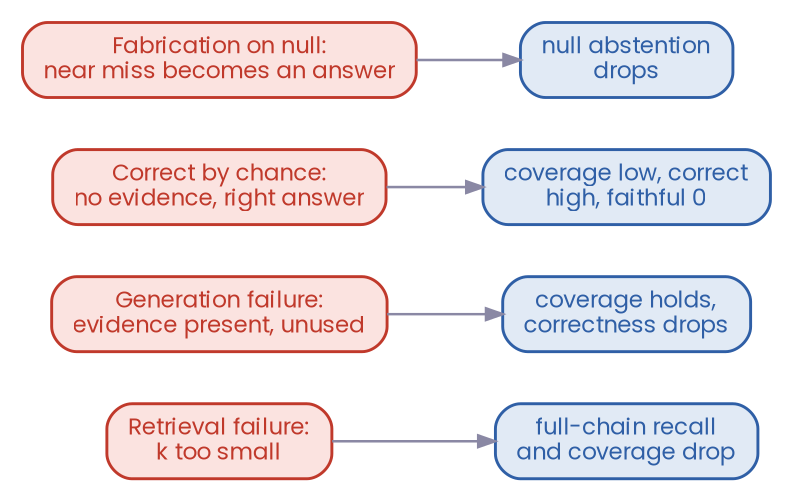

*Own construction. The cell reproduces each row with the simulator's knobs.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    a["Retrieval failure:<br/>k too small"]
    b["Generation failure:<br/>evidence present, unused"]
    c["Correct by chance:<br/>no evidence, right answer"]
    d["Fabrication on null:<br/>near miss becomes an answer"]
    m1["full-chain recall<br/>and coverage drop"]
    m2["coverage holds,<br/>correctness drops"]
    m3["coverage low, correct<br/>high, faithful 0"]
    m4["null abstention<br/>drops"]
    a --> m1
    b --> m2
    c --> m3
    d --> m4
    class a fail
    class b fail
    class c fail
    class d fail
    class m1 tool
    class m2 tool
    class m3 tool
    class m4 tool
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [3]:
def vector(name, cfg, gen):
    df = rk.run_benchmark(cfg, retriever, gen, questions, chunks, seed=1); s = rk.summarize(df)
    return {"failure": name, "full_chain@k": s["full_chain@k"], "coverage": s["coverage"], "correct": s["correct"], "faithful": s["faithful"], "null_abstained": s["null_abstained"]}
scen = [
    vector("healthy baseline, k=10", rk.RunConfig("h", mode="hybrid", k=10), rk.MockGenerator()),
    vector("retrieval failure, k=2", rk.RunConfig("r", mode="hybrid", k=2), rk.MockGenerator()),
    vector("generation failure, evidence unused (position_depth=0.95), k=10", rk.RunConfig("g", mode="hybrid", k=10), rk.MockGenerator(position_depth=0.95)),
    vector("correct by chance (p_parametric=1), k=1", rk.RunConfig("c", mode="hybrid", k=1), rk.MockGenerator(p_parametric=1.0)),
    vector("fabrication on null (p_parametric=1), k=10", rk.RunConfig("f", mode="hybrid", k=10), rk.MockGenerator(p_parametric=1.0)),
]
table(pd.DataFrame(scen), "One knob per row; read which column moved")

failure,full_chain@k,coverage,correct,faithful,null_abstained
"healthy baseline, k=10",0.889,0.944,0.917,1.000,1.000
"retrieval failure, k=2",0.556,0.722,0.667,1.000,1.000
"generation failure, evidence unused (position_depth=0.95), k=10",0.889,0.944,0.667,1.000,1.000
"correct by chance (p_parametric=1), k=1",0.000,0.444,0.750,0.000,0.000
"fabrication on null (p_parametric=1), k=10",0.889,0.944,0.750,0.000,0.000


| Symptom in production | The metric that moves | The metric that stays flat, and lies |
|---|---|---|
| Answers are wrong and the evidence was never in the context. | Full-chain recall at k, coverage. | Faithfulness, since an abstention is faithful. |
| The evidence was in the context and the answer is still wrong or missing. | Correctness, with coverage held at 1.0. | Recall and coverage, which say retrieval did its job. |
| The answer is right and nothing in the context supports it. | Faithfulness at 0 with correctness at 1. | Correctness on its own. |
| The system answers questions the corpus cannot answer. | Null abstention. | Every retrieval metric, because null questions have no gold. |

## 3 · The attribution 2x2, over the whole benchmark

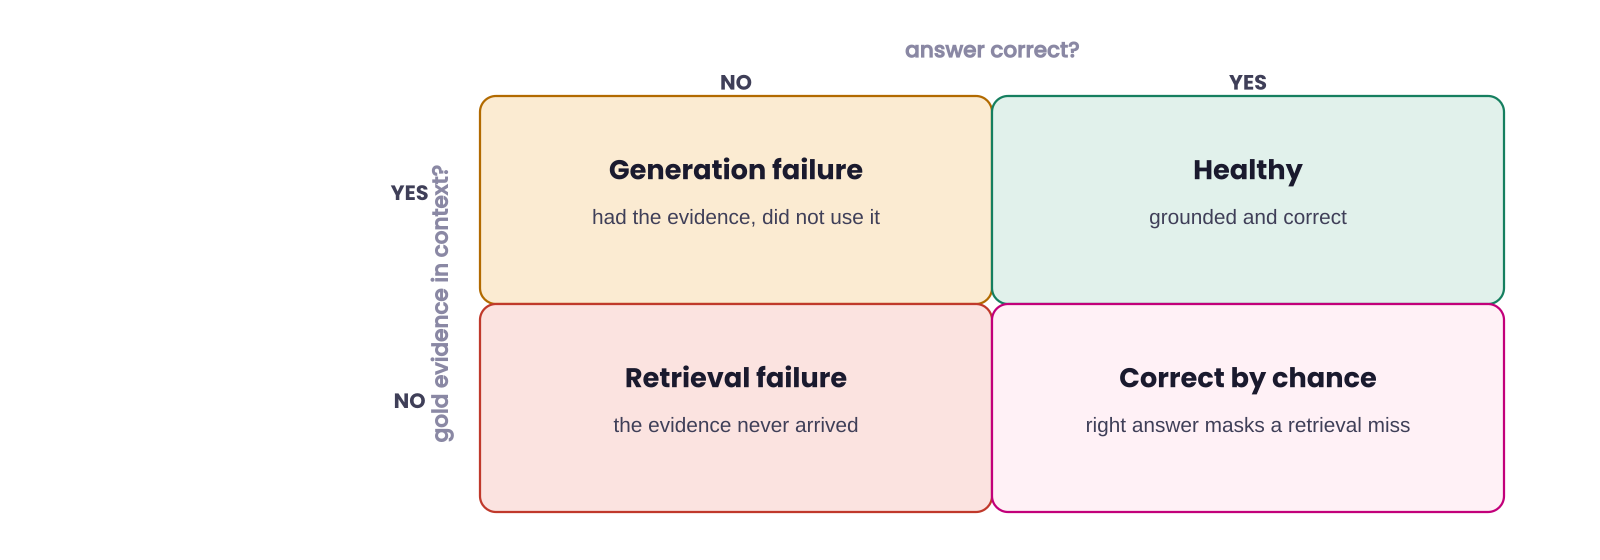

*Own construction. The cell below counts every question into a cell under a generator with realistic knobs.*

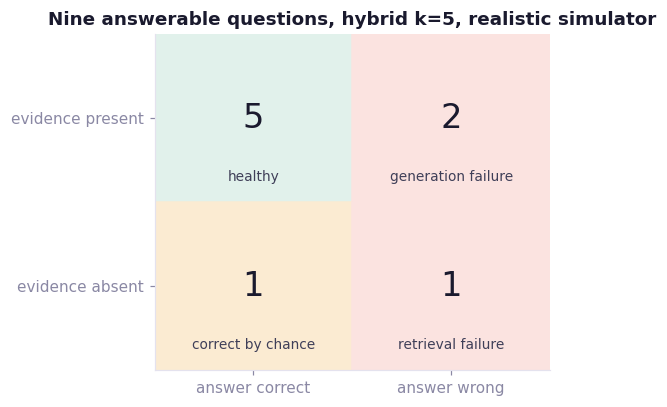

qid,type,coverage,correct,faithful,cell,answer
q01,inference,0.000,1.000,0.000,correct by chance,"Vega Dynamics, 2023"
q02,inference,1.000,1.000,1.000,healthy,Northlight Ventures [h1:0:7e02f268] [h2:0:3e515569]
q03,inference,0.500,0.000,1.000,retrieval failure,INSUFFICIENT EVIDENCE. Found part of the chain [l2:0:9af35c53] but could not con
q04,comparison,1.000,1.000,1.000,healthy,"Orbis Networks, 500 million dollars against 310 million dollars [o1:0:005c3c5b]"
q05,comparison,1.000,1.000,1.000,healthy,"Orbis Networks, 1.4 billion dollars against 212 million dollars [h4:0:27b2079e]"
q06,comparison,1.000,1.000,1.000,healthy,"Yes, 150 million dollars against 40 million dollars [s1:0:0f1fecc9] [h2:0:3e5155"
q07,temporal,1.000,0.000,1.000,generation failure,INSUFFICIENT EVIDENCE. Found part of the chain [o1:0:005c3c5b] but could not con
q08,temporal,1.000,1.000,0.000,healthy,"After, in May 2025 against September 2024"
q09,temporal,1.000,0.000,1.000,generation failure,INSUFFICIENT EVIDENCE. Found part of the chain [l3:0:acebc108] but could not con
q10,null,nan,1.000,1.000,healthy,INSUFFICIENT EVIDENCE. The corpus does not state this.


In [4]:
realistic = rk.MockGenerator(p_parametric=0.3, position_depth=0.35)
df = rk.run_benchmark(rk.RunConfig("realistic_k5", mode="hybrid", k=5), retriever, realistic, questions, chunks, store, seed=3)
counts = df[df["type"] != "null"]["cell"].value_counts()
grid = np.array([[counts.get("healthy", 0), counts.get("generation failure", 0)], [counts.get("correct by chance", 0), counts.get("retrieval failure", 0)]])
import matplotlib.pyplot as plt
fig_, ax = plt.subplots(figsize=(5.2, 3.8))
colours = [[rk.palette.GREEN_SOFT, rk.palette.RED_SOFT], [rk.palette.COST_SOFT, rk.palette.RED_SOFT]]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1, color=colours[i][j])); ax.text(j + 0.5, 1.5 - i, f"{grid[i, j]}", ha="center", va="center", fontsize=22, color=rk.palette.INK)
labels = [["healthy", "generation failure"], ["correct by chance", "retrieval failure"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, 1.15 - i, labels[i][j], ha="center", va="center", fontsize=9, color=rk.palette.SOFT)
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(["answer correct", "answer wrong"]); ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(["evidence absent", "evidence present"]); ax.grid(False)
ax.set_title("Nine answerable questions, hybrid k=5, realistic simulator"); plt.tight_layout(); plt.show()
table(df[["qid", "type", "coverage", "correct", "faithful", "cell", "answer"]], "Per question. Null questions are scored on abstention and fall outside the 2x2.")

| Cell | Owner | The first thing to change |
|---|---|---|
| Evidence present, answer correct | Nobody. Healthy. | Nothing; add the case to the regression set. |
| Evidence present, answer wrong | Generation. | Grounding instruction, ordering, abstention policy, model. |
| Evidence absent, answer correct | Nobody yet, and it will break on the next release. | Treat as a retrieval failure; the parametric memory that rescued it is not a system property. |
| Evidence absent, answer wrong | Retrieval. | Chunking, hybrid, N, k, or decomposition for the dependent hops. |

One row deserves a second look: a question can land in the healthy cell with faithfulness at 0, which happens when the evidence was present and the answer was right but nothing was cited. The 2x2 keys on evidence presence; the citation contract is what the faithfulness column enforces, and a healthy-but-uncited answer is a contract violation that will not survive a model change.

## 4 · Calibrating a judge so its verdict can be trusted

An LLM judge is a scorer with its own biases. Calibration is the loop that measures it against people before it is allowed to gate anything.

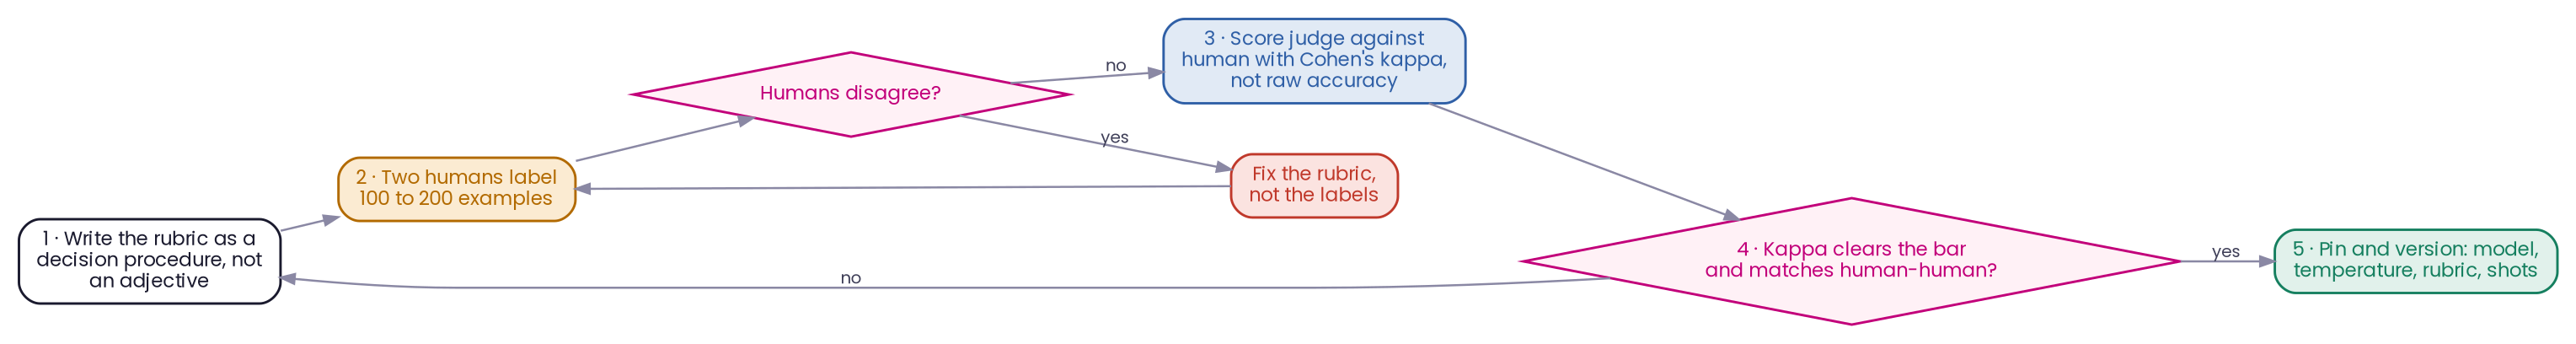

*The calibration loop from the advanced-track deck. The cell builds a labelled set and scores four judges against it.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    r["1 · Write the rubric as a<br/>decision procedure, not<br/>an adjective"]
    h["2 · Two humans label<br/>100 to 200 examples"]
    dis{"Humans disagree?"}
    fixr["Fix the rubric,<br/>not the labels"]
    k["3 · Score judge against<br/>human with Cohen's kappa,<br/>not raw accuracy"]
    bar{"4 · Kappa clears the bar<br/>and matches human-human?"}
    pin["5 · Pin and version: model,<br/>temperature, rubric, shots"]
    r --> h
    h --> dis
    dis -->|yes| fixr
    fixr --> h
    dis -->|no| k
    k --> bar
    bar -->|no| r
    bar -->|yes| pin
    class h cost
    class dis dec
    class fixr fail
    class k tool
    class bar dec
    class pin ok
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [5]:
import re
# A labelled set: answers from runs with mixed knobs. The human label is whether the answer's claims were supported by evidence,
# which the simulator records honestly in grounded_path (a real study would have two people label this against the rubric).
labelled = []
for knobs, seed in [({}, 0), ({"p_parametric": 0.6}, 1), ({"p_parametric": 0.6, "position_depth": 0.5}, 2), ({"position_depth": 0.6}, 3), ({"p_parametric": 0.9}, 4)]:
    gen = rk.MockGenerator(**knobs, seed=seed)
    for k in [2, 5]:
        for q in questions:
            pool_ = retriever.hybrid(q.text, k=50); packed_ = rk.pack(pool_, texts, evidence_cap=6000, k=k)
            a = gen.answer(q, packed_.chunk_ids, texts)
            supported = a.grounded_path or (q.answer is not None and not a.missing and not a.abstained and a.used_spans)
            labelled.append({"qid": q.qid, "answer": a.text, "citations": a.citations, "human_faithful": int(bool(supported))})
lab = pd.DataFrame(labelled)
print(f"{len(lab)} labelled answers, {lab['human_faithful'].mean():.0%} faithful (a skewed set, as real ones are)")

def judge_always_pass(row): return 1
def judge_holistic(row):     # passes anything that looks grounded: it has a citation or it abstains
    return int(bool(row["citations"]) or "INSUFFICIENT EVIDENCE" in row["answer"])
def judge_verbosity(row):    # longer answers look more thorough
    return int(len(row["answer"]) > 40)
def judge_procedural(row):   # every number and proper noun in the answer must appear in a cited chunk; abstentions pass
    if "INSUFFICIENT EVIDENCE" in row["answer"]: return 1
    if not row["citations"]: return 0
    cited = " ".join(texts.get(c, "") for c in row["citations"]).lower()
    claims = [t.lower() for t in re.findall(r"\b[A-Z][a-z]+\b|\b\d{4}\b|\b\d+\b", re.sub(r"\[.*?\]", "", row["answer"]))]
    claims = [c for c in claims if c not in {"yes", "no", "after", "before", "the", "orbis", "networks"} or c in cited]
    return int(all(c in cited for c in claims)) if claims else 0
rows = []
for name, fn in [("always pass", judge_always_pass), ("holistic: has a citation or abstains", judge_holistic), ("verbosity: long answers pass", judge_verbosity), ("procedural: every claim in a cited chunk", judge_procedural)]:
    verdict = lab.apply(fn, axis=1)
    rows.append({"judge": name, "raw agreement with human": round(float((verdict == lab["human_faithful"]).mean()), 3), "Cohen's kappa": round(rk.cohen_kappa(lab["human_faithful"].tolist(), verdict.tolist()), 3)})
table(pd.DataFrame(rows), "Four judges against the human labels. Read kappa, not agreement.")

120 labelled answers, 79% faithful (a skewed set, as real ones are)


judge,raw agreement with human,Cohen's kappa
always pass,0.792,0.000
holistic: has a citation or abstains,0.900,0.632
verbosity: long answers pass,0.900,0.688
procedural: every claim in a cited chunk,0.958,0.864


In [6]:
# Position bias in a pairwise judge: swap A and B and require the verdict to hold
rng = np.random.default_rng(0)
pairs = [(lab.iloc[i], lab.iloc[j]) for i, j in rng.integers(0, len(lab), size=(60, 2)) if lab.iloc[i]["human_faithful"] != lab.iloc[j]["human_faithful"]]
def pairwise_biased(a, b):   # prefers the first when the two look similar
    sa, sb = judge_procedural(a), judge_procedural(b)
    return "A" if sa > sb else ("B" if sb > sa else "A")
def pairwise_swapped(a, b):
    return "B" if pairwise_biased(b, a) == "A" else "A"
consistent = sum(1 for a, b in pairs if pairwise_biased(a, b) == pairwise_swapped(a, b))
print(f"{len(pairs)} pairs with different human labels; verdict held after swapping A and B in {consistent} ({consistent / max(1, len(pairs)):.0%}). Ties resolved toward A are the bias.")

19 pairs with different human labels; verdict held after swapping A and B in 18 (95%). Ties resolved toward A are the bias.


| Bias | How it shows up | The control |
|---|---|---|
| Position | In pairwise comparison the first answer wins ties. | Swap A and B and require the verdict to hold; discard or rejudge the rest. |
| Verbosity | Longer answers score higher. In this labelled set the verbosity judge agreed well with the humans for a spurious reason: unsupported answers from the simulator happen to be short and abstentions long, so length stood in for faithfulness. On a set where fabrications are verbose the same judge fails. | Cap length, or normalise for it in the rubric, and never accept a judge because it agreed on one set. |
| Self-preference | A judge favours output from its own model family. | Judge with a different family from the generator where you can. |
| Scale compression | A 1 to 10 scale collapses to 7s and 8s. | Binary or three-point rubrics with explicit criteria. |
| Leniency on grounding | Plausible unsupported claims pass, which is what the holistic judge did. | Force span-level checking, which is what the procedural judge did. |
| The skewed-set trap | An always-pass judge scores high raw agreement on a set that is mostly faithful. | Report Cohen's kappa; it is near zero for that judge. |

## 5 · Measure your noise before you believe a delta

The same configuration, run under different seeds, gives a spread. A delta smaller than that spread is not a result.

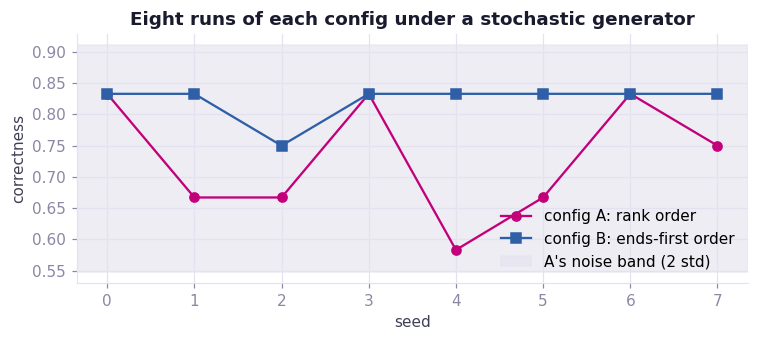

comparison,mean,spread,verdict
A alone,0.729,"std 0.091, band 0.181",
B alone,0.823,"std 0.027, band 0.055",
"B minus A, unpaired, against A's band",0.093,band 0.181,inside the band: not a result
"B minus A, paired per seed",0.093,2 SE 0.066; B ahead in 5 of 8 seeds,outside 2 SE: likely real


In [7]:
noisy = rk.MockGenerator(position_depth=0.4)
cfg_a = rk.RunConfig("a", mode="hybrid", k=8); cfg_b = rk.RunConfig("b", mode="hybrid", k=8, order="ends")
va = rk.variance(cfg_a, retriever, noisy, questions, chunks, seeds=range(8)); vb = rk.variance(cfg_b, retriever, noisy, questions, chunks, seeds=range(8))
fig_, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(range(8), va["runs"], marker="o", label="config A: rank order"); ax.plot(range(8), vb["runs"], marker="s", label="config B: ends-first order")
ax.axhspan(va["mean"] - va["band"], va["mean"] + va["band"], color=rk.palette.RULE, alpha=0.6, label="A's noise band (2 std)")
ax.set_xlabel("seed"); ax.set_ylabel("correctness"); ax.set_title("Eight runs of each config under a stochastic generator"); ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
diff = np.array(vb["runs"]) - np.array(va["runs"]); se2 = 2 * diff.std(ddof=1) / np.sqrt(len(diff))
table(pd.DataFrame([{"comparison": "A alone", "mean": round(va["mean"], 3), "spread": f"std {va['std']:.3f}, band {va['band']:.3f}", "verdict": ""},
                    {"comparison": "B alone", "mean": round(vb["mean"], 3), "spread": f"std {vb['std']:.3f}, band {vb['band']:.3f}", "verdict": ""},
                    {"comparison": "B minus A, unpaired, against A's band", "mean": round(vb["mean"] - va["mean"], 3), "spread": f"band {va['band']:.3f}", "verdict": "inside the band: not a result" if abs(vb["mean"] - va["mean"]) < va["band"] else "outside the band"},
                    {"comparison": "B minus A, paired per seed", "mean": round(float(diff.mean()), 3), "spread": f"2 SE {se2:.3f}; B ahead in {int((diff > 0).sum())} of {len(diff)} seeds", "verdict": "outside 2 SE: likely real" if abs(diff.mean()) > se2 else "inside 2 SE: not a result"}]),
      "The same delta, judged two ways")

| If | Then | Because |
|---|---|---|
| Both configs ran under the same seeds. | Judge the paired per-seed difference against its own standard error, as the last row does. Here the unpaired band calls the ordering gain noise and the paired test calls it real. | Pairing removes the seed's contribution to the spread; the unpaired band double-counts it. |
| Only one config's spread is known. | Compare the delta against that band and call anything inside it not a result. | You measured a coin flip. |
| The delta is outside the noise on the tuning slice. | Check the frozen slice next. | A real gain that only lives on the tuning slice is tuning, not improvement. |
| The band itself is wide, as it is here with twelve questions. | Grow the set before you grow the system. | A benchmark this small cannot certify a change of a few points without pairing. |

## 6 · The release gate: two candidates, one ships

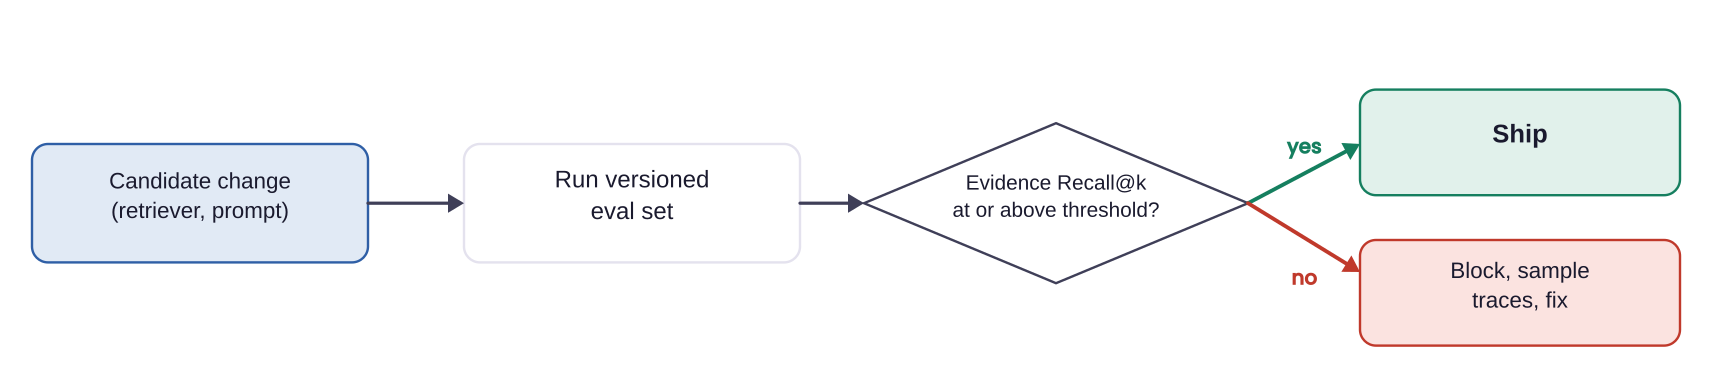

*From the advanced-track deck. The cell runs a baseline and two candidates under the same stochastic generator and the same eight seeds, then through gate() and the ship tree.*

In [8]:
SEEDS = range(8)
def multi(cfg):
    return [rk.run_benchmark(cfg, retriever, noisy, questions, chunks, seed=sd) for sd in SEEDS]
def mean_summary(frames, name):
    return pd.concat([rk.summarize(f) for f in frames], axis=1).mean(axis=1).round(3).rename(name)
base_runs = multi(rk.RunConfig("baseline", mode="hybrid", k=5)); base = mean_summary(base_runs, "baseline")
cand = {"A: k=10 with dedup": rk.RunConfig("A", mode="hybrid", k=10, dedup_jaccard=0.7), "B: k=3 to cut cost": rk.RunConfig("B", mode="hybrid", k=3)}
cand_runs = {name: multi(cfg) for name, cfg in cand.items()}
for name, frames in cand_runs.items():
    display(verdict_style(rk.gate(base, mean_summary(frames, name), tolerance=0.02, cost_warn=0.15), "verdict"))
    fb = np.mean([f[f["frozen"]]["correct"].mean() for f in base_runs]); fc = np.mean([f[f["frozen"]]["correct"].mean() for f in frames])
    print(f"   {name}: frozen-slice correctness {fb:.3f} -> {fc:.3f}, averaged over {len(SEEDS)} seeds of the stochastic generator\n")

metric,before,after,delta,verdict
full_chain@k,0.778,0.889,0.111,ok
recall@k,0.833,0.944,0.111,ok
correct,0.698,0.833,0.135,ok
faithful,1.000,1.000,0.000,ok
null_abstained,1.000,1.000,0.000,ok
evidence_tokens,229.200,427.200,+86%,WARN


   A: k=10 with dedup: frozen-slice correctness 0.875 -> 0.875, averaged over 8 seeds of the stochastic generator



metric,before,after,delta,verdict
full_chain@k,0.778,0.667,-0.111,BLOCK
recall@k,0.833,0.778,-0.055,BLOCK
correct,0.698,0.552,-0.146,BLOCK
faithful,1.000,1.000,0.000,ok
null_abstained,1.000,1.000,0.000,ok
evidence_tokens,229.200,143.900,-37%,ok


   B: k=3 to cut cost: frozen-slice correctness 0.875 -> 0.667, averaged over 8 seeds of the stochastic generator



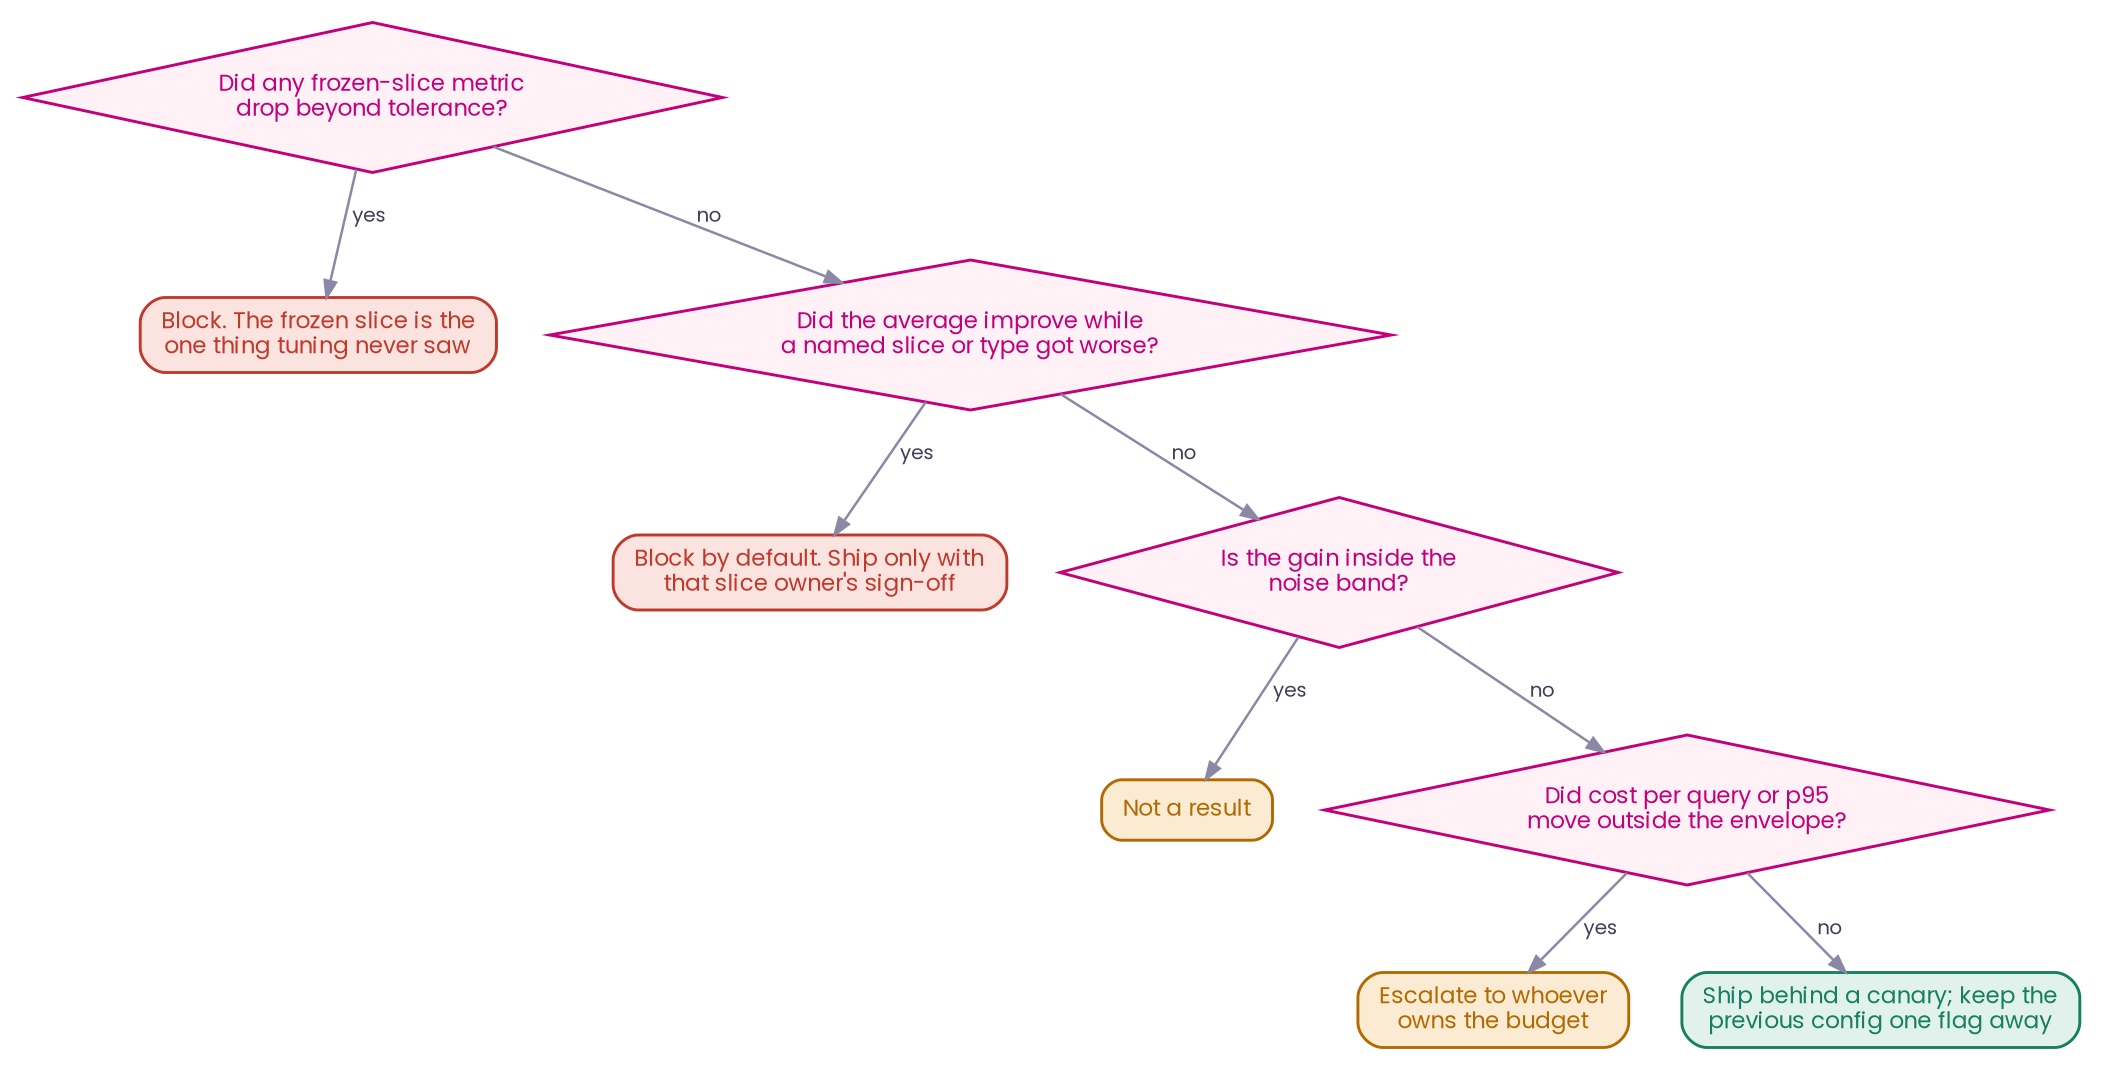

*The ship tree from the advanced-track deck, executed below on both candidates.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart TD
    q1{"Did any frozen-slice metric<br/>drop beyond tolerance?"}
    b1["Block. The frozen slice is the<br/>one thing tuning never saw"]
    q2{"Did the average improve while<br/>a named slice or type got worse?"}
    b2["Block by default. Ship only with<br/>that slice owner's sign-off"]
    q3{"Is the gain inside the<br/>noise band?"}
    b3["Not a result"]
    q4{"Did cost per query or p95<br/>move outside the envelope?"}
    b4["Escalate to whoever<br/>owns the budget"]
    ship["Ship behind a canary; keep the<br/>previous config one flag away"]
    q1 -->|yes| b1
    q1 -->|no| q2
    q2 -->|yes| b2
    q2 -->|no| q3
    q3 -->|yes| b3
    q3 -->|no| q4
    q4 -->|yes| b4
    q4 -->|no| ship
    class q1 dec
    class b1 fail
    class q2 dec
    class b2 fail
    class q3 dec
    class b3 cost
    class q4 dec
    class b4 cost
    class ship ok
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [9]:
SHIP_TREE = [
    {"q": "Did any frozen-slice metric drop beyond tolerance?", "test": lambda f: f["frozen_drop"] > 0.02, "yes": "BLOCK: the frozen slice is the one thing tuning never saw", "no": None, "show": lambda f: f"frozen drop={f['frozen_drop']:.3f}"},
    {"q": "Did the average improve while a named type got worse?", "test": lambda f: f["worst_type_delta"] < -0.02 and f["avg_delta"] > 0, "yes": "BLOCK by default; ship only with that slice owner's sign-off", "no": None, "show": lambda f: f"avg {f['avg_delta']:+.3f}, worst type {f['worst_type_delta']:+.3f}"},
    {"q": "Is the gain inside the paired noise (2 SE)?", "test": lambda f: abs(f["avg_delta"]) < f["se2"], "yes": "not a result: measure again with a larger set", "no": None, "show": lambda f: f"2 SE={f['se2']:.3f}"},
    {"q": "Did cost per query move outside the envelope (+15 percent)?", "test": lambda f: f["cost_delta"] > 0.15, "yes": "ESCALATE: quality bought with unbudgeted cost is the budget owner's decision", "no": "SHIP behind a canary, previous config one flag away", "show": lambda f: f"cost {f['cost_delta']:+.0%}"},
]
def facts_for(frames):
    bc = np.array([f["correct"].mean() for f in base_runs]); cc = np.array([f["correct"].mean() for f in frames]); d = cc - bc
    fb = np.mean([f[f["frozen"]]["correct"].mean() for f in base_runs]); fc = np.mean([f[f["frozen"]]["correct"].mean() for f in frames])
    bt = pd.concat([f[f["type"] != "null"] for f in base_runs]).groupby("type")["correct"].mean(); ct = pd.concat([f[f["type"] != "null"] for f in frames]).groupby("type")["correct"].mean()
    return {"frozen_drop": float(fb - fc), "avg_delta": float(d.mean()), "se2": float(2 * d.std(ddof=1) / np.sqrt(len(d))), "worst_type_delta": float((ct - bt).min()),
            "cost_delta": float(np.mean([f["evidence_tokens"].mean() for f in frames]) / np.mean([f["evidence_tokens"].mean() for f in base_runs]) - 1)}
for name, frames in cand_runs.items():
    display(table(decision(SHIP_TREE, facts_for(frames)), f"Ship decision for candidate {name}"))

question,measured,answer
Did any frozen-slice metric drop beyond tolerance?,frozen drop=0.000,no
Did the average improve while a named type got worse?,"avg +0.135, worst type +0.042",no
Is the gain inside the paired noise (2 SE)?,2 SE=0.070,no
Did cost per query move outside the envelope (+15 percent)?,cost +86%,yes
Outcome,,ESCALATE: quality bought with unbudgeted cost is the budget owner's decision


question,measured,answer
Did any frozen-slice metric drop beyond tolerance?,frozen drop=0.208,yes
Outcome,,BLOCK: the frozen slice is the one thing tuning never saw


| If | Then | Because |
|---|---|---|
| A frozen-slice metric dropped beyond tolerance, as candidate B's did. | Block. | Someone experiences that regression as an outage of their use case, and the slice was never tuned on. |
| The average rose while one type fell. | Block by default; ship with the owner's sign-off. | The mean is not the user. |
| The gain is inside the noise band. | Not a result. | A delta smaller than the variance is chance. |
| Quality improved outside the paired noise, the frozen slice held, and cost left the envelope, as candidate A did. | Escalate; do not silently accept. | Quality bought with unbudgeted cost is a decision for whoever owns the budget, not for the harness. |
| Everything holds. | Canary a traffic slice against the control, roll forward, or revert by config. | Revert by config is a pointer change; revert by redeploy is an incident. |

The nightly run on unchanged code is not redundant. It is how you detect corpus drift, upstream model updates and judge drift, three things that change the system without anyone committing anything.

## Failure points in this layer

| Failure | What you saw | The fix |
|---|---|---|
| Answer-only metric | Correct by chance scored 1.0 on correctness with nothing in the context. | Faithfulness next to correctness; the 2x2. |
| Averaged metric | The healthy mean hid the inference type at 0.33 in notebook 01, and the ship tree checks the worst type here. | Segment by type, slice and tenant. |
| Uncalibrated judge | The always-pass judge scored high raw agreement and a kappa near zero. | Calibrate against human labels, report kappa, pin the judge. |
| Unmeasured noise | The ordering change landed inside the unpaired band and outside the paired one. | Measure variance once, pair runs under the same seeds, write the band down. |
| Tuning to the set | Candidate B improved cost and dropped the frozen slice. | The frozen slice gates, and production failures feed the set. |

## What to carry out of this notebook

| # | The line worth remembering |
|---|---|
| 1 | Every metric has a blind spot, and the layered set exists so that each blind spot is covered by the layer beside it. |
| 2 | The attribution 2x2 turns a benchmark run into four owners; correct-by-chance is a retrieval failure that has not happened yet. |
| 3 | A judge is a scorer with biases; calibrate it against people, report Cohen's kappa, control for position and verbosity, and pin it as a release artefact. |
| 4 | Measure run-to-run variance before believing any delta, and pair runs under the same seeds; on a twelve-question set the unpaired band is wide enough to hide a real gain. |
| 5 | The gate blocks on the frozen slice and on any named slice that got worse, escalates on cost, and ships behind a canary with the old config one flag away. |

**Next: 07 · Tokens and cost.** Candidate A improved quality and left the cost envelope. Notebook 07 prices exactly that: four token categories on a real request, a cache simulator that shows the timestamp bug, the break-even for a cached prefix, and the cost levers pulled in order with measured savings.

## Interview corner

| Question an interviewer may ask | What a strong answer does | Red flag |
|---|---|---|
| Your LLM judge says quality went up. How would you know if the judge is wrong? | Re-checks kappa against fresh human labels, swaps pairwise positions, and looks for verbosity or self-preference drift; treats the judge as a versioned artefact. | Trusts the judge because it is a strong model. |
| A change raises average quality 6 percent and one business unit says it got worse. Ship it? | Blocks by default, measures that unit's slice, and ships only with the owner's sign-off and a canary. | Ships on the average. |
| What would block your release? | A frozen-slice drop, a regression case that now fails, a named slice worse while the mean holds. Names cost as an escalation rather than a block. | Lists metrics without a threshold or an owner. |